In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris, load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

Original shape: (150, 4)
Reduced shape:  (150, 2)
Variance explained: [72.96244541 22.85076179]
Total variance kept: 95.8%


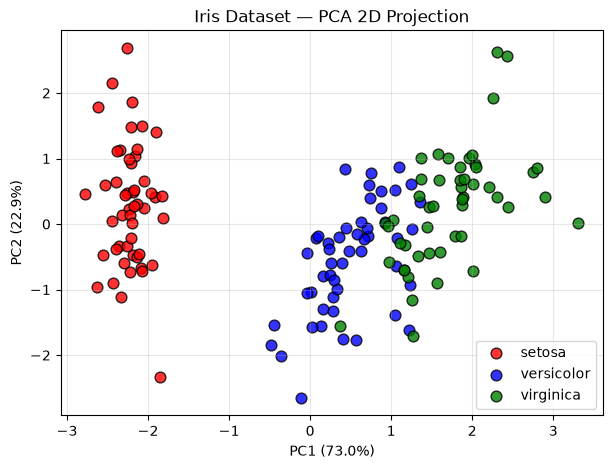

In [2]:
# Cell 2 — Version 1: Iris 4D → 2D visualisation
iris = load_iris()
X, y = iris.data, iris.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca    = PCA(n_components=2)
X_pca  = pca.fit_transform(X_scaled)

print(f"Original shape: {X.shape}")
print(f"Reduced shape:  {X_pca.shape}")
print(f"Variance explained: {pca.explained_variance_ratio_*100}")
print(f"Total variance kept: {pca.explained_variance_ratio_.sum()*100:.1f}%")

plt.figure(figsize=(7, 5))
colors = ['red', 'blue', 'green']
for k, (col, name) in enumerate(zip(colors, iris.target_names)):
    mask = y == k
    plt.scatter(X_pca[mask,0], X_pca[mask,1],
                c=col, label=name, edgecolors='k', s=60, alpha=0.8)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('Iris Dataset — PCA 2D Projection')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

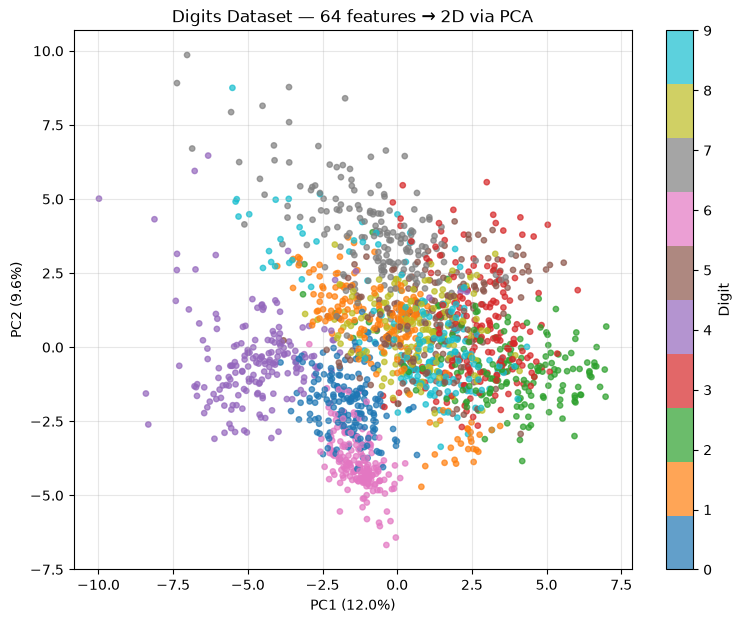

Digits cluster even in 2D — PCA preserves structure ✅


In [3]:
# Cell 3 — Version 2: Digits dataset 64D → 2D
digits = load_digits()
X, y   = digits.data, digits.target

X_scaled = StandardScaler().fit_transform(X)
pca      = PCA(n_components=2)
X_pca    = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1],
                      c=y, cmap='tab10', s=15, alpha=0.7)
plt.colorbar(scatter, label='Digit')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('Digits Dataset — 64 features → 2D via PCA')
plt.grid(True, alpha=0.3); plt.show()
print("Digits cluster even in 2D — PCA preserves structure ✅")

In [4]:
# Cell 4 — Version 3: PCA in a Pipeline
digits = load_digits()
X, y   = digits.data, digits.target
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                    test_size=0.2, random_state=42)

pipe_no_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=1000, random_state=42))
])

pipe_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca',    PCA(n_components=30)),
    ('clf',    LogisticRegression(max_iter=1000, random_state=42))
])

pipe_no_pca.fit(X_train, y_train)
pipe_pca.fit(X_train, y_train)

acc_no_pca = accuracy_score(y_test, pipe_no_pca.predict(X_test))
acc_pca    = accuracy_score(y_test, pipe_pca.predict(X_test))

print(f"Without PCA (64 features): {acc_no_pca*100:.1f}%")
print(f"With PCA    (30 features): {acc_pca*100:.1f}%")
print("Almost same accuracy with half the features ✅")

Without PCA (64 features): 97.2%
With PCA    (30 features): 96.1%
Almost same accuracy with half the features ✅


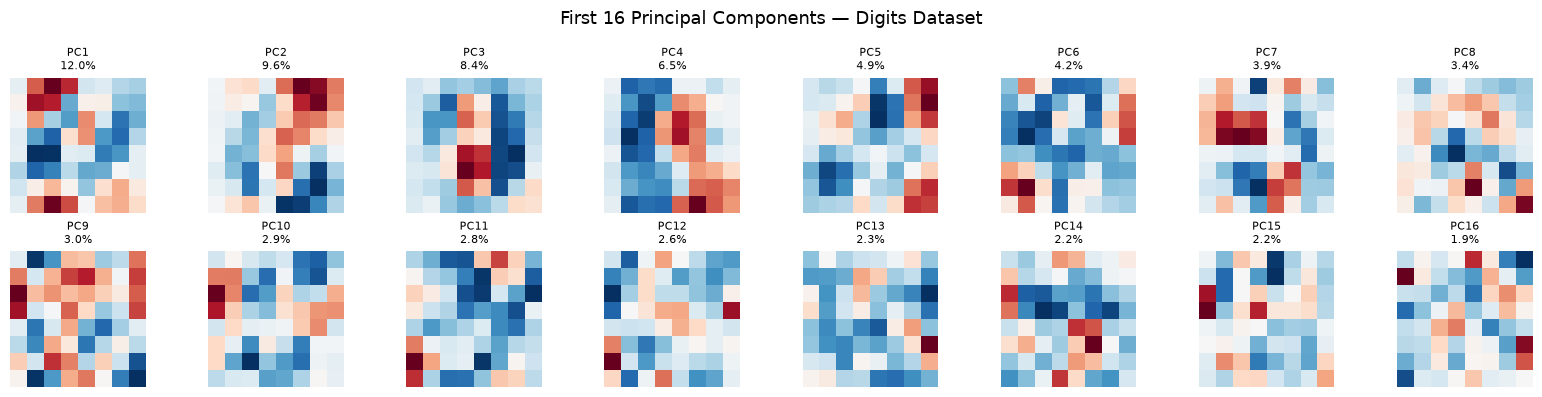

Each PC is a 'pattern' the model found in the digit images ✅


In [5]:
# Cell 5 — Version 4: visualise what PCs look like (digits)
digits   = load_digits()
X        = StandardScaler().fit_transform(digits.data)
pca      = PCA(n_components=16)
pca.fit(X)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(pca.components_[i].reshape(8, 8), cmap='RdBu_r')
    ax.set_title(f'PC{i+1}\n{pca.explained_variance_ratio_[i]*100:.1f}%',
                 fontsize=8)
    ax.axis('off')
plt.suptitle('First 16 Principal Components — Digits Dataset', fontsize=13)
plt.tight_layout(); plt.show()
print("Each PC is a 'pattern' the model found in the digit images ✅")